# Single Harmonic
This looks at how much information can be extracted about the seasonal cycle, restricting ourselves to a single harmonic.

In [50]:
import copy
import sys
import os

from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.surface_flux_taylor import name_square
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_water, rho_water, Stefan_Boltzmann, R, R_v
from isca_tools.utils import numerical
from isca_tools.utils.radiation import get_heat_capacity
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget import get_temp_fourier_analytic, get_temp_fourier_numerical, \
    get_temp_extrema_analytic, get_param_dimensionless, phase_coef_conversion
from isca_tools.utils.fourier import fourier_series
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

import jobs.thesis_season.thesis_figs.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [153]:
# exp_name = [f"thesis_season/column/depth={i}/k=1_abs=0_2" for i in [5, 20]]
exp_name = [f"thesis_season/column/depth={i}/odp_const" for i in [5]]
ds_base = utils.load_ds(exp_name=exp_name, lat_min=30, var_keep=utils.var_keep+['drag_q', 'olr'])
ds = utils.get_annual_zonal_mean(ds_base)

  0%|          | 0/1 [00:00<?, ?it/s]

In [118]:
_, coef_amp, coef_phase = utils.get_fourier_fit_xr(ds.time, ds.temp_surf, n_harmonics=1, pad_coefs_phase=True)
_, coef_sw_amp, coef_sw_phase = utils.get_fourier_fit_xr(ds.time, ds.swdn_sfc, n_harmonics=1, pad_coefs_phase=True)
coef_amp = np.abs(coef_amp.sel(harmonic=1))
coef_phase = coef_phase.sel(harmonic=1)
coef_sw_amp = np.abs(coef_sw_amp.sel(harmonic=1))

In [119]:
f = 1/(ds.time.size*utils.day_seconds)
ds['depth_eff'] = get_heat_capacity(c_p_water, rho_water, coef_sw_amp*np.sin(coef_phase)/(2*np.pi*f)/coef_amp, True)/ds.depth

In [120]:
# sf = (1-0.31)*(1-0.2)/(0.2+(1-0.31)*(1-0.2))

In [121]:
# Compute radiative temp from lowest model level temp
x = ds.temp_atm.to_numpy().flatten()
y = ds.temp_rad.to_numpy().flatten()
x = x[:,np.newaxis]
a, resid, _, _ = np.linalg.lstsq(x, y, rcond=-1)            # force with zero intercept
r_square = 1 - resid / (y.size * y.var())

In [122]:
temp_rad3 = ((ds.olr + ds.lwdn_sfc - np.exp(-ds.odp_surf)*Stefan_Boltzmann*ds.temp_surf**4) / (2*Stefan_Boltzmann * (1-np.exp(-ds.odp_surf))))**0.25

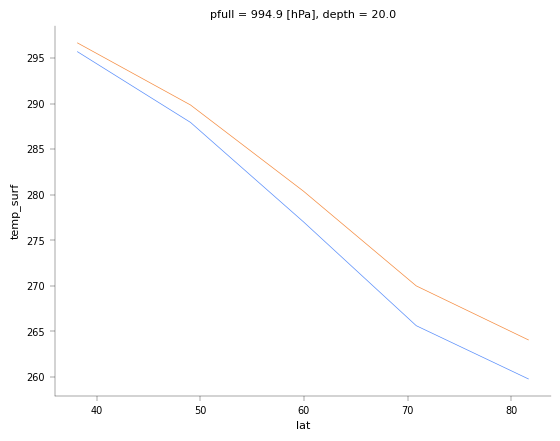

In [130]:
ds.temp_surf.mean(dim='time').isel(depth=0).plot()
ds.temp_surf.mean(dim='time').isel(depth=1).plot()

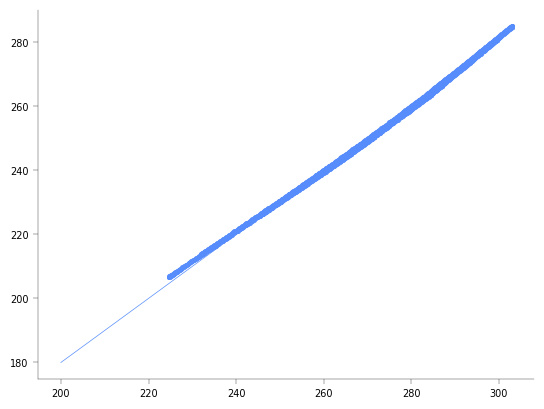

In [126]:
plt.scatter(ds.temp_atm, temp_rad3)
plt.plot([200, 300], np.asarray([200, 300])-20)

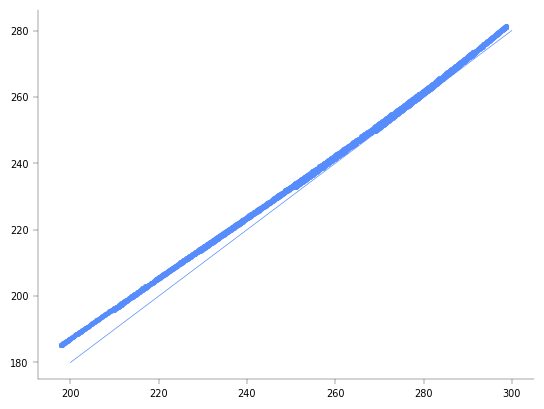

In [106]:
plt.scatter(ds.temp_atm, temp_rad3)
plt.plot([200, 300], np.asarray([200, 300])-20)

<xarray.DataArray (time: 360, depth: 2, lat: 5)> Size: 29kB
array([[[262.79431881, 252.73735591, 241.34052383, 231.07027265,
         226.13423962],
        [270.18484963, 261.8632778 , 251.33792981, 240.88017243,
         235.27019317]],

       [[262.55161898, 252.44155898, 241.01249534, 230.76174904,
         225.85916172],
        [270.06362822, 261.72535633, 251.19804727, 240.75822583,
         235.16486028]],

       [[262.31108752, 252.148134  , 240.68677323, 230.45531736,
         225.58536212],
        [269.94273612, 261.58781833, 251.05852211, 240.63660596,
         235.05977962]],

       ...,

       [[263.53450062, 253.63824008, 242.33793386, 232.00871733,
         226.96914828],
        [270.55017599, 262.27894156, 251.75938428, 241.24804202,
         235.58769423]],

       [[263.2858442 , 253.33578281, 242.00329783, 231.69372651,
         226.68914896],
        [270.42817249, 262.1401133 , 251.61862756, 241.12508707,
         235.48161129]],

       [[263.03908636, 253.03546017, 241.67080811, 231.38092524,
         226.41085828],
        [270.30638529, 262.00153572, 251.47813367, 241.00246331,
         235.37577725]]])
Coordinates:
  * lat      (lat) float64 40B 38.16 49.06 59.95 70.83 81.65
    pfull    float64 8B 994.9
  * depth    (depth) float64 16B 5.0 20.0
  * time     (time) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359

In [58]:
temp_rad2 = ((ds.olr - np.exp(-ds.odp_surf)*Stefan_Boltzmann*ds.temp_surf**4) / (Stefan_Boltzmann * (1-np.exp(-ds.odp_surf))))**0.25

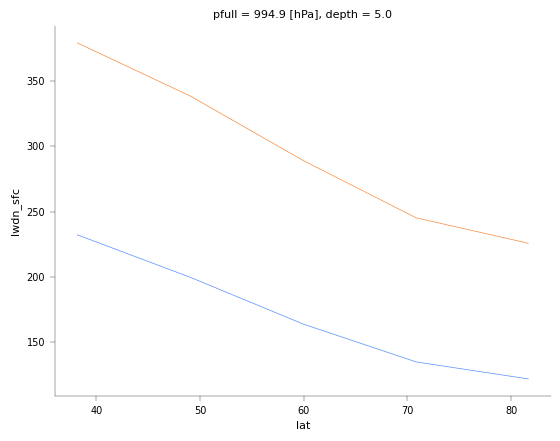

In [59]:
ds.olr.mean(dim='time').isel(depth=0).plot()
ds.lwdn_sfc.mean(dim='time').isel(depth=0).plot()

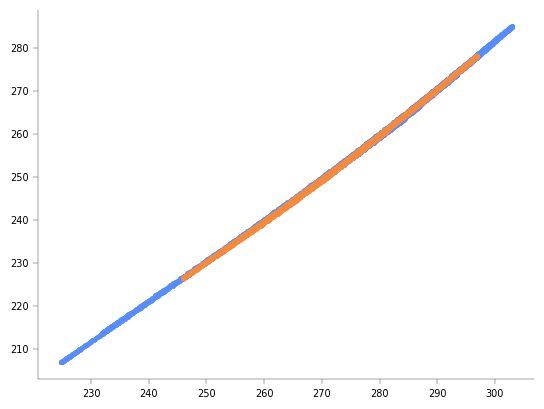

In [93]:
plt.scatter(ds.temp_atm.isel(depth=0), temp_rad3.isel(depth=0))
plt.scatter(ds.temp_atm.isel(depth=1), temp_rad3.isel(depth=1))

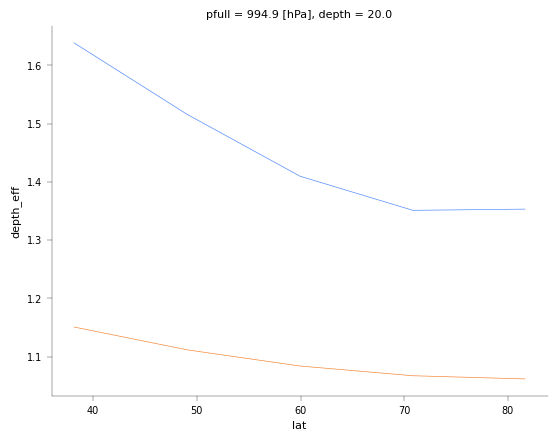

In [61]:
(ds.depth_eff).sel(depth=5).plot(color='C0')
(ds.depth_eff).sel(depth=20).plot(color='C1')

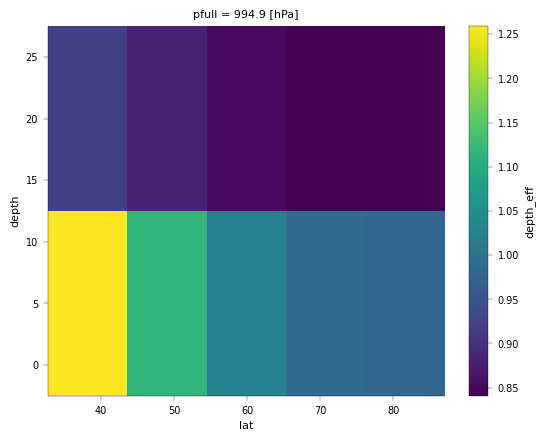

In [85]:
ds.depth_eff.plot()

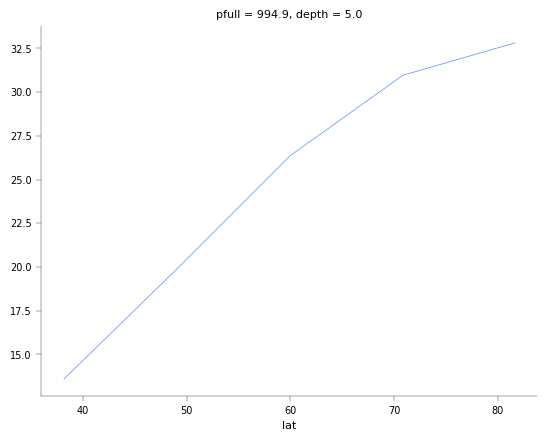

In [48]:
coef_amp.plot()

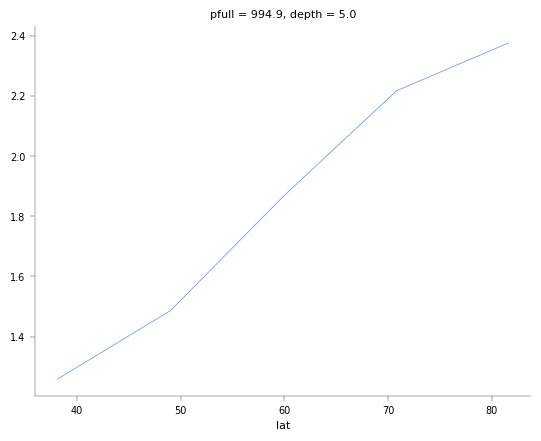

In [45]:
coef_phase.plot()

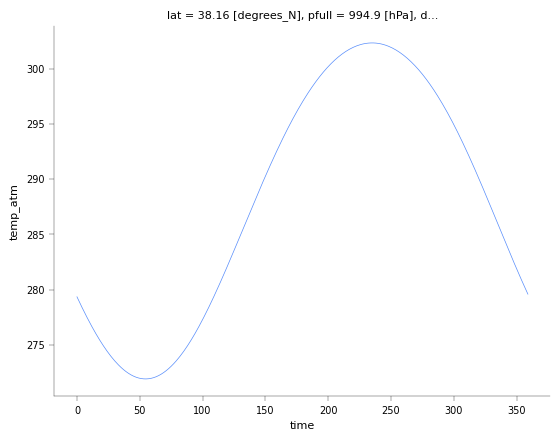

In [25]:
ds.temp_atm.isel(lat=0).plot()

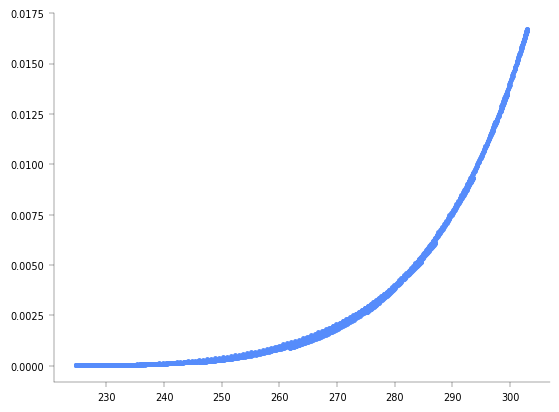

In [154]:
plt.scatter(ds.temp_atm, ds.q_atm)

Text(0, 0.5, '$r_a$')

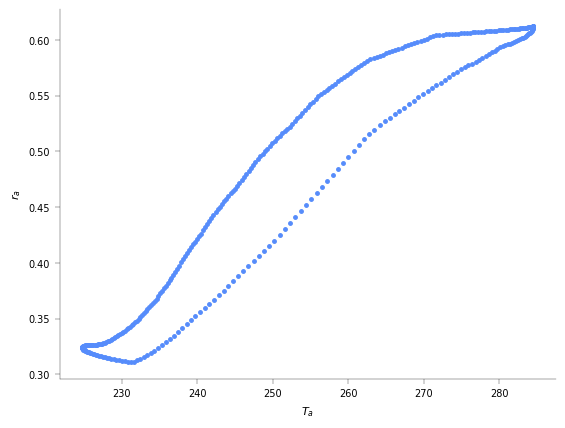

In [148]:
plt.scatter(ds.temp_atm.isel(depth=0, lat=-1), ds.rh_atm.isel(depth=0, lat=-1))
plt.xlabel('$T_a$')
plt.ylabel('$r_a$')

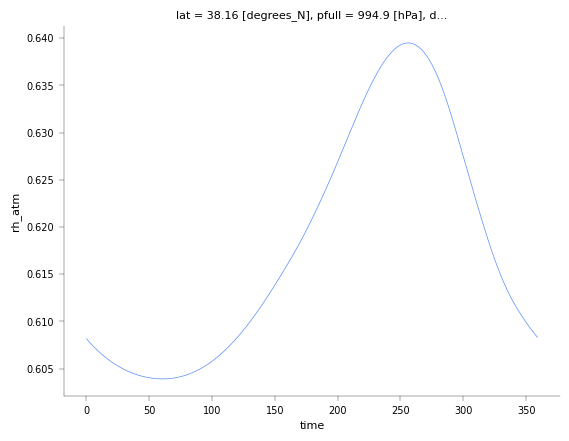

In [22]:
ds.rh_atm.isel(lat=0).plot()

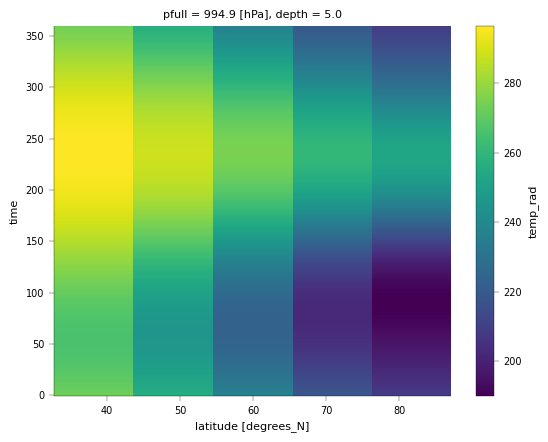

In [15]:
ds.squeeze().temp_rad.plot()